In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Notebook: Split Training Dataset by Datastrip

This notebook splits the dataset into training, validation, and test sets at the datastrip level. Datastrips are treated as indivisible units to avoid spatial and acquisition leakage, ensuring that windows from the same datastrip do not appear in multiple splits.

Purpose: Create balanced splits with similar Scene Classification Layer (SCL) distributions across training, validation, and test sets, while maintaining acquisition-level independence.

In [ ]:
IN_PARQUET = "parquet/windows_best_s2_with_vza_angleDiffLE4_withSCL.parquet"
OUT_PARQUET = "parquet/windows_best_s2_with_vza_angleDiffLE4_withSCL_split_byDatastrip.parquet"

RANDOM_SEED = 42
SPLITS = [("train", 0.80), ("val", 0.15), ("test", 0.05)]
N_CLASSES = 12  # SCL 0..11

## Define Helper Functions

- `scl_dict_to_vec(d)`: Converts SCL histogram data (stored as a dictionary) into a fixed-length vector of counts for each SCL class.
- `l1(v, t)`: Computes the L1 distance (sum of absolute differences) between two vectors. Used for measuring the difference between the current and target SCL distributions.

In [20]:
def scl_dict_to_vec(d):
    if d is None or (isinstance(d, float) and pd.isna(d)):
        return np.zeros(N_CLASSES, dtype=np.int64)
    if isinstance(d, str):
        try:
            d = json.loads(d)
        except Exception:
            return np.zeros(N_CLASSES, dtype=np.int64)
    if not isinstance(d, dict):
        return np.zeros(N_CLASSES, dtype=np.int64)

    v = np.zeros(N_CLASSES, dtype=np.int64)
    for k, val in d.items():
        try:
            kk = int(k)
            if 0 <= kk < N_CLASSES:
                v[kk] = int(val)
        except Exception:
            pass
    return v

def l1(v, t):
    return np.abs(v - t).sum()

In [21]:
# --- load ---
df = pd.read_parquet(IN_PARQUET)
df["datastrip"] = df["datastrip"].astype(str)

scl_vecs = np.vstack([scl_dict_to_vec(x) for x in df["scl_counts"].tolist()])
N = len(df)

From this point, dataset splitting is performed at the datastrip level. Each datastrip is treated as an indivisible unit: we first compute the aggregate SCL pixel distribution per datastrip, and then assign entire datastrips to the training, validation, and test splits such that the overall SCL distribution across splits is as similar as possible.

This strategy is primarily motivated by the need to avoid spatial and acquisition leakage. A datastrip corresponds to a single satellite acquisition geometry, characterized by a shared orbit pass, sensor configuration, illumination conditions, atmospheric state, viewing angle, and spatially contiguous coverage. Consequently, windows extracted from the same datastrip are highly correlated.

If windows were randomly split across train/validation/test sets, neighboring windows originating from the same datastrip would likely appear in different splits. This would result in effectively the same image content being observed during both training and evaluation, leading to data leakage. Such leakage can artificially inflate validation and test performance, giving a misleading impression of model generalization.

This issue is particularly relevant in super-resolution and cross-sensor learning tasks, where the model learns not only spatial structures but also sensor- and acquisition-specific characteristics, including noise patterns, radiometric scaling, atmospheric effects, and view-angle–dependent artifacts. All of these factors are strongly datastrip-specific. If a datastrip appears in both training and testing sets, the model can implicitly recognize that acquisition, even when spatial locations differ, thereby violating the independence assumption required for a fair evaluation.

By enforcing datastrip-level separation and performing SCL balancing after grouping, we preserve acquisition-level independence while maintaining comparable scene composition across splits.

**References**
- Feng, H., Wang, Y., Li, Z., Zhang, N., Zhang, Y., Gao, Y.; *Information Leakage in Deep Learning-Based Hyperspectral Image Classification: A Survey*. **Remote Sensing**, 2023, 15(15), 3793, https://doi.org/10.3390/rs15153793
- Kuhn, M., Johnson, K.; *Applied Machine Learning for Tabular Data*, 2023, Section 3.3 — Information Leakage, https://aml4td.org/chapters/initial-data-splitting.html#sec-leakage

In [ ]:
# --- group aggregate ---
group_to_idx = {}
for i, ds in enumerate(df["datastrip"].to_numpy()):
    group_to_idx.setdefault(ds, []).append(i)

group_ids = list(group_to_idx.keys())
G = len(group_ids)

group_counts = np.zeros(G, dtype=np.int64)
group_scl = np.zeros((G, N_CLASSES), dtype=np.int64)

for gi, ds in enumerate(group_ids):
    idxs = group_to_idx[ds]
    group_counts[gi] = len(idxs)
    group_scl[gi] = scl_vecs[idxs].sum(axis=0)

overall_scl = group_scl.sum(axis=0)
overall_windows = int(group_counts.sum())

split_names = [s[0] for s in SPLITS]
split_fracs = np.array([s[1] for s in SPLITS], dtype=float)

In [ ]:
# target window counts (by windows)
target_windows = np.floor(split_fracs * overall_windows).astype(int)
target_windows[0] += overall_windows - target_windows.sum()

# target scl totals (by pixels)
target_scl = (overall_scl[None, :] * split_fracs[:, None]).round().astype(np.int64)
# fix rounding per class to match overall exactly
diff = overall_scl - target_scl.sum(axis=0)
order = np.argsort(-split_fracs)
for c in range(N_CLASSES):
    d = int(diff[c])
    j = 0
    while d != 0:
        si = order[j % len(order)]
        target_scl[si, c] += 1 if d > 0 else -1
        d += -1 if d > 0 else 1
        j += 1

We split by datastrip (block-level splitting), and assign datastrips to train/val/test so that each split’s aggregated SCL pixel histogram stays as close as possible to the desired target histogram, while keeping split sizes near 80/15/5.

The assignement is said "greedy", meaning that each datastrip is assigned to the split that minimizes the imbalance at the time of assignment, without revisiting previous assignments.

This algorithm does **not guarantee** the globally optimal solution, but gives a good approximation at **much lower cost** (finding the true optimum would be an NP-hard partitioning problem.)

In [ ]:
# --- Assignment using DELTA cost ---
# Place big groups first for stability
perm = np.argsort(-group_counts)

assigned_group = np.full(G, -1, dtype=int)
curr_windows = np.zeros(len(SPLITS), dtype=np.int64)
curr_scl = np.zeros((len(SPLITS), N_CLASSES), dtype=np.int64)

for gi in perm:
    g_cnt = group_counts[gi]
    g_s = group_scl[gi]

    best_split = None
    best_cost = None

    for si in range(len(SPLITS)):
        # soft capacity: allow overshoot a bit, but penalize it
        new_w = curr_windows[si] + g_cnt
        over = max(0, new_w - target_windows[si])

        # delta L1 toward target (the KEY fix)
        old_dist = l1(curr_scl[si], target_scl[si])
        new_dist = l1(curr_scl[si] + g_s, target_scl[si])
        delta_dist = new_dist - old_dist  # can be negative (good)

        # cost = delta toward SCL target + window overshoot penalty
        cost = delta_dist + 1_000_000 * over  # hard-ish discourage big overshoots

        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_split = si

    assigned_group[gi] = best_split
    curr_windows[best_split] += g_cnt
    curr_scl[best_split] += g_s

In [25]:
# --- map back to rows ---
group_split_map = {group_ids[gi]: split_names[assigned_group[gi]] for gi in range(G)}
df["split"] = df["datastrip"].map(group_split_map)

In [ ]:
# --- diagnostics ---
def norm_dist(v):
    s = v.sum()
    return (v / s) if s > 0 else v.astype(float)

overall_dist = norm_dist(overall_scl)

print("Groups:", G, "| Windows:", overall_windows)
print("Target windows:", dict(zip(split_names, target_windows)))
print("Actual windows:", df["split"].value_counts().to_dict())

for si, name in enumerate(split_names):
    d = norm_dist(curr_scl[si])
    l1_to_overall = float(np.abs(d - overall_dist).sum())
    print(f"{name}: windows={int(curr_windows[si])}  total_pixels={int(curr_scl[si].sum()):,}  L1_to_overall={l1_to_overall:.6f}")

Groups: 802 | Windows: 30934
Target windows: {'train': np.int64(24748), 'val': np.int64(4640), 'test': np.int64(1546)}
Actual windows: {'train': 24748, 'val': 4640, 'test': 1546}


In [29]:
df.to_parquet(OUT_PARQUET, index=False)
print("Saved:", OUT_PARQUET)

Saved: windows_best_s2_with_vza_angleDiffLE4_withSCL_split_byDatastrip.parquet


## Visualisation

Top 5 SCL classes per split (by % within split):

train:
  SCL  4:  63.71%
  SCL  5:  27.25%
  SCL  6:   7.14%
  SCL 10:   1.29%
  SCL  7:   0.18%

val:
  SCL  4:  63.42%
  SCL  5:  27.06%
  SCL  6:   7.69%
  SCL 10:   1.03%
  SCL  7:   0.26%

test:
  SCL  4:  59.63%
  SCL  5:  25.37%
  SCL  6:  10.54%
  SCL 10:   2.12%
  SCL 11:   0.63%


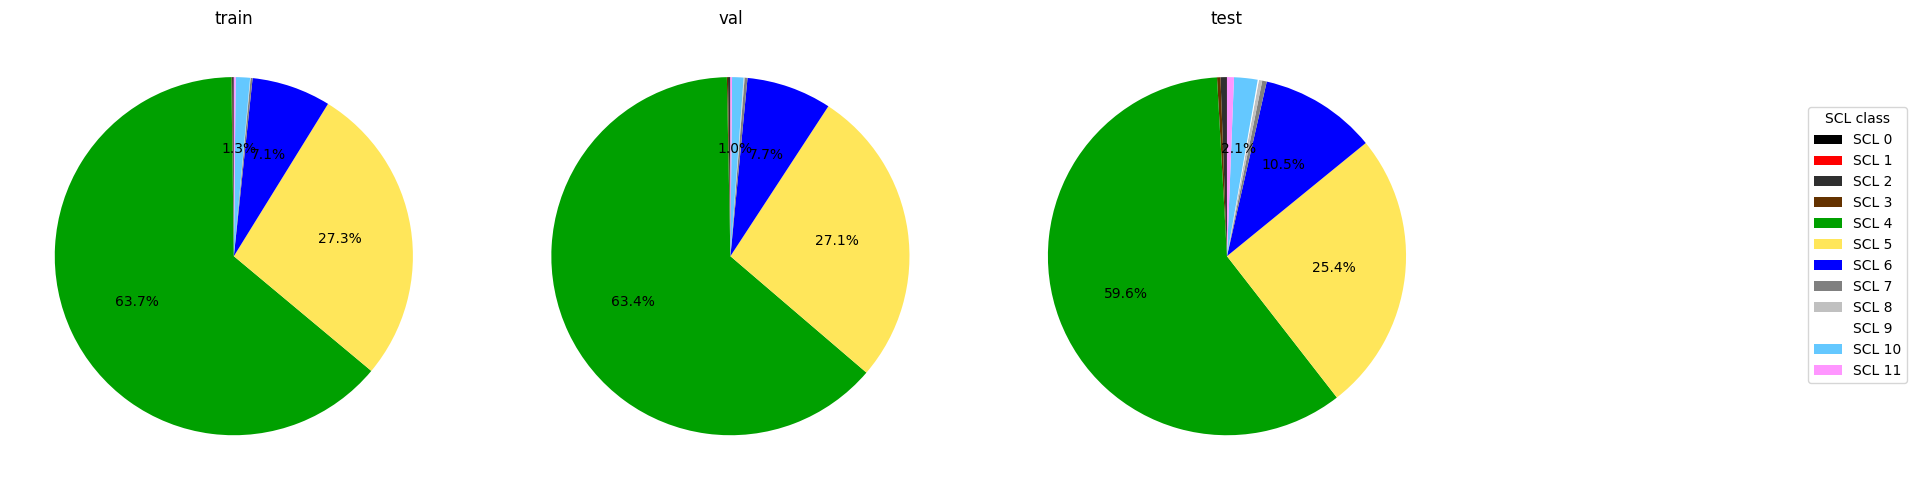

In [ ]:
SCL_RGB = {
    0:  [0, 0, 0],         # No Data
    1:  [255, 0, 0],       # Saturated/defective
    2:  [47, 47, 47],      # Dark features/shadows
    3:  [100, 50, 0],      # Cloud shadows
    4:  [0, 160, 0],       # Vegetation
    5:  [255, 230, 90],    # Not-vegetated
    6:  [0, 0, 255],       # Water
    7:  [128, 128, 128],   # Unclassified
    8:  [192, 192, 192],   # Cloud medium prob
    9:  [255, 255, 255],   # Cloud high prob
    10: [100, 200, 255],   # Thin cirrus
    11: [255, 150, 255],   # Snow/ice
}

# Desired order
desired_order = ["train", "val", "test"]
splits = [s for s in desired_order if s in set(df["split"].unique())]
if not splits:
    splits = sorted(df["split"].unique().tolist())

labels = [f"SCL {i}" for i in range(N_CLASSES)]

# Convert RGB->matplotlib color (0..1)
colors = [tuple(np.array(SCL_RGB[i]) / 255.0) for i in range(N_CLASSES)]

# Aggregate totals per split
totals_by_split = {}
pct_by_split = {}
for split_name in splits:
    g = df[df["split"] == split_name]
    totals = np.zeros(N_CLASSES, dtype=np.int64)
    for d in g["scl_counts"]:
        totals += scl_dict_to_vec(d)
    totals_by_split[split_name] = totals
    total_pixels = totals.sum()
    pct_by_split[split_name] = (totals / total_pixels * 100.0) if total_pixels else np.zeros(N_CLASSES)

# Plot 3 pies
fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 5))
if len(splits) == 1:
    axes = [axes]

for ax, split_name in zip(axes, splits):
    totals = totals_by_split[split_name]
    total_pixels = totals.sum()

    if total_pixels == 0:
        ax.text(0.5, 0.5, f"{split_name}\n(no pixels)", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.pie(
        totals,                    # all classes, fixed order
        colors=colors,             # fixed color per class
        startangle=90,
        autopct=lambda p: f"{p:.1f}%" if p >= 1 else ""  # hide tiny labels
    )
    ax.set_title(split_name)

# Single legend (consistent)
legend_handles = [Patch(facecolor=colors[i], label=labels[i]) for i in range(N_CLASSES)]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="SCL class"
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Note: the 3 main classes are Vegetation (4), Not-vegetated (5) and Water (6).